# Day 3 — Uplift models: estimating individual treatment effects

**Goal:** a per-customer score τ̂(x) estimating how much the women's email changes *that customer's* visit probability. This is CATE estimation (conditional average treatment effect), a.k.a. uplift modeling.

## The estimators, and when each wins — intuition before code

**T-learner** ("two models"): fit E[Y|X] on treated rows, fit E[Y|X] on control rows, subtract the predictions. Transparent, but each model sees only half the data, and the difference of two independently-regularized models can invent structure (each model's smoothing errors don't cancel).

**X-learner**: uses each arm's model to *impute* the other arm's counterfactual, producing a per-customer pseudo-effect, then regresses those pseudo-effects directly and blends the two arms' regressions by the propensity score. The effect function itself gets regularized — which helps when the effect τ(x) is smoother/simpler than the outcome functions (usually true), and when arms are imbalanced (not the case here, but the mechanism still stabilizes estimates).

**Causal forest** (econml `CausalForestDML`): honest random forests built to split on *treatment-effect heterogeneity* rather than outcome levels, with "honesty" (separate samples decide splits vs estimate effects) and cross-fitted nuisance models guarding against overfitting. Strong when heterogeneity is genuinely nonlinear/interactive; also gives per-customer CIs.

(An **S-learner** — one model with treatment as a feature — is the fourth classic; we skip it because regularization can shrink the treatment feature's role toward zero, biasing effects toward homogeneity. Worth knowing for interviews.)

## The overfitting trap and out-of-fold discipline

A flexible model can memorize noise and *appear* to find huge heterogeneity. All scores used for validation are **out-of-fold**: 5-fold splitting where each customer is scored by models that never trained on them. Every downstream evaluation inherits this honesty.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import load_data, CONTROL
FIG_DIR = ROOT / "reports" / "figures"
ARM_COLORS = {"No E-Mail": "#6A6A6A", "Mens E-Mail": "#0072B2", "Womens E-Mail": "#CC7A00"}
pd.set_option("display.max_columns", 30)

df = load_data()

In [2]:
from src.models import build_features, oof_meta_learners, oof_outcome_model, SEED

sub = df[df["segment"].isin(["Womens E-Mail", CONTROL])].copy().reset_index(drop=True)
sub["T"] = (sub["segment"] == "Womens E-Mail").astype(int)

X = build_features(sub)
y_visit = sub["visit"].to_numpy()
T = sub["T"].to_numpy()
print(f"n={len(sub):,}  treated={T.sum():,}  control={(1-T).sum():,}  features={X.shape[1]}")
X.head(3)

n=42,693  treated=21,387  control=21,306  features=9


,recency,history,mens,womens,newbie,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,142.44,1,0,0,1.0,0.0,1.0,0.0
1,6,329.08,1,1,1,0.0,0.0,0.0,1.0
2,7,180.65,0,1,1,1.0,0.0,0.0,1.0


In [3]:
%%time
tau_t, tau_x = oof_meta_learners(X, y_visit, T)          # T- and X-learner OOF CATEs
p_outcome = oof_outcome_model(X, y_visit, T)             # naive baseline: P(visit), not uplift

CPU times: total: 1min 17s
Wall time: 7.46 s


In [4]:
ate = y_visit[T == 1].mean() - y_visit[T == 0].mean()
summary = pd.DataFrame({
    "T-learner": pd.Series(tau_t).describe(),
    "X-learner": pd.Series(tau_x).describe(),
}).round(4)
print(f"Overall ATE (visit): {ate:.4f} -- CATE means should sit near this")
summary

Overall ATE (visit): 0.0452 -- CATE means should sit near this


,T-learner,X-learner
count,42693.0000,42693.0000
mean,0.0456,0.0456
std,0.0395,0.0309
min,-0.1859,-0.0494
25%,0.0143,0.0159
50%,0.0463,0.0557
75%,0.0762,0.0731
max,0.3279,0.1827


**Sanity check passed if:** both CATE means sit near the 0.045 ATE (they estimate the same average), while the spread shows the models *think* effects range from near-zero to ~3× the average. Whether that spread is real signal or noise is exactly what notebook 04 tests — never trust a CATE histogram at face value.

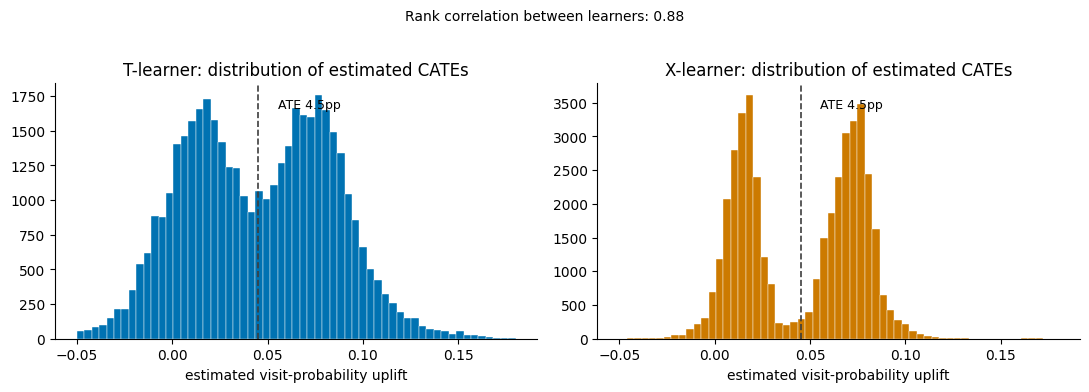

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.linspace(-0.05, 0.18, 60)
for ax, (name, tau, color) in zip(
        axes, [("T-learner", tau_t, "#0072B2"), ("X-learner", tau_x, "#CC7A00")]):
    ax.hist(tau, bins=bins, color=color, edgecolor="white", linewidth=0.3)
    ax.axvline(ate, color="#3d3d3d", lw=1.2, ls="--")
    ax.annotate(f"ATE {ate*100:.1f}pp", (ate, ax.get_ylim()[1] * 0.9), fontsize=9,
                xytext=(ate + 0.01, ax.get_ylim()[1] * 0.9))
    ax.set_title(f"{name}: distribution of estimated CATEs")
    ax.set_xlabel("estimated visit-probability uplift")
    ax.spines[["top", "right"]].set_visible(False)
rank_corr = pd.Series(tau_t).corr(pd.Series(tau_x), method="spearman")
fig.suptitle(f"Rank correlation between learners: {rank_corr:.2f}", y=1.02, fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "day3_cate_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

## Causal forest (econml)

Same task, third estimator family. `CausalForestDML` residualizes outcome and treatment with cross-fitted nuisance models (the "DML" part — here treatment is a known coin flip, so its model has little to do), then fits an honest forest on the residuals. `min_samples_leaf=50` keeps leaf-level effect estimates stable. Runs in a few minutes.

In [6]:
%%time
from econml.dml import CausalForestDML
from sklearn.linear_model import LogisticRegression
from src.models import make_reg

cf = CausalForestDML(
    model_y=make_reg(),
    model_t=LogisticRegression(max_iter=1000),
    discrete_treatment=True,
    n_estimators=500, min_samples_leaf=50,
    cv=3, random_state=SEED,
)
cf.fit(y_visit, T, X=X.values)
tau_cf = cf.effect(X.values)
print(f"Causal forest CATEs: mean {tau_cf.mean():.4f}, sd {tau_cf.std():.4f}")
print(f"Rank corr with X-learner: {pd.Series(tau_cf).corr(pd.Series(tau_x), method='spearman'):.2f}")

Causal forest CATEs: mean 0.0455, sd 0.0341
Rank corr with X-learner: 0.85
CPU times: total: 1min
Wall time: 7.23 s


*Note on honesty:* the forest's `effect()` on training rows is protected differently than our meta-learners — honest trees estimate leaf effects on samples not used to place splits, and nuisances are cross-fitted (`cv=3`). We still treat the OOF meta-learners as the primary scores for validation and use the forest as a cross-estimator check.

In [7]:
oof = pd.DataFrame({
    "tau_t": tau_t, "tau_x": tau_x, "p_outcome": p_outcome,
    "y_visit": y_visit, "spend": sub["spend"].to_numpy(), "T": T,
})
if "tau_cf" in dir():
    oof["tau_cf"] = tau_cf
oof.to_csv(ROOT / "data" / "oof_cates.csv", index=False)
print("saved", (ROOT / "data" / "oof_cates.csv"), oof.shape)

saved C:\Projects\Causal_Inference\email-uplift-targeting\data\oof_cates.csv (42693, 7)


## Where this leaves us

Three estimators, all centered on the ATE, agreeing substantially on *who* is most responsive (high rank correlations) while disagreeing in the tails. Predictions are saved for notebooks 04 (do these rankings actually concentrate uplift?) and 05 (what should the business do with them?).